(assurance_planning)=
# Assurance Planning via Simulation

:::{post} May 2026
:tags: experimentation, decision analysis, power analysis, assurance, simulation
:category: intermediate, reference
:author: Nathaniel Forde
:::

## The question planners are actually asking

When a team approves an experiment, the question they are silently asking is whether the experiment will be useful. The frequentist quantity called "power" answers a different question entirely: given some specific effect size we have not observed, what is the probability the experiment crosses a fixed threshold? The slippage between these two questions has produced a generation of experimental plans calibrated to invented effect sizes rather than to the beliefs the planners actually hold.

Assurance is the Bayesian alternative, and its construction is mechanical: draw an effect from the prior, generate a dataset, fit the model, apply the decision rule, repeat. The result is a single number with a clear meaning: the probability that the experiment is about to conclude what its stakeholders need it to. The engine is the same whether the response is continuous (revenue per visitor) or binary (conversion); we develop it on the Gaussian case first and confirm the conclusion is invariant to the response scale. This notebook is the first of three on the lifecycle of a Bayesian experiment; see {ref}`sensitivity_confounding` for the interpretation counterpart and {ref}`meta_analysis_experiments` for the synthesis counterpart.

:::{admonition} Where this lands in regulatory practice
:class: note

The assurance framing here is not only a product-analytics convenience. The FDA's 2026 draft guidance on Bayesian methodology in clinical trials defines *Bayesian power* as the probability of meeting the success criterion averaged over a prior distribution {cite:p}`fda2026bayesian`, which is assurance under another name, and formalises the success rule as $\Pr(\text{effect} > a) > c$ (the rule used below, with $a = 0$ and $c = 0.95$). The same guidance separates the *design prior* that generates the synthetic trials from the *analysis prior* used in inference, which is exactly the split the generative and inference models below are built on. The setting differs from product experimentation; the machinery is identical.
:::

In [1]:
import warnings

from dataclasses import dataclass

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns

from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-darkgrid")
rng = np.random.default_rng(42)
RANDOM_SEED = 42

### The scenario

The running scenario across this notebook and its two successors is a product-experimentation question: an e-commerce team is evaluating a redesigned checkout flow. The continuous outcome is revenue per visitor; the binary outcome is conversion. We will not commit to a particular vertical or product; the structure is generic to any A/B test with one of these outcome types. What matters is that the same prior beliefs and the same decision rule will be asked of two different likelihoods. The Gaussian case will carry the argument; the Bernoulli case will confirm it travels.

In [3]:
@dataclass
class EffectPrior:
    """Prior beliefs about a treatment effect, on the scale of the outcome."""

    mu: float
    sigma: float

    def sample(self, rng, size=1):
        return rng.normal(self.mu, self.sigma, size=size)

## Power and assurance: two questions in the same wardrobe

Power and assurance share an interface and answer different questions. Power conditions on a specific effect size $\theta_0$ that the planner has been pressed into naming, and computes the probability of rejecting the null:

$$
\text{Power}(N) = P\!\left(\text{reject } H_0 \mid \theta = \theta_0,\; N\right).
$$

The conditioning bar is the load-bearing part. The planner who has confidently named $\theta_0$ has implicitly used up the uncertainty that motivated the experiment in the first place. Assurance refuses the substitution. Instead it integrates over the planner's prior beliefs about the effect:

$$
\text{Assurance}(N) = \int P\!\left(\text{decision} \mid \theta,\; N\right)\, \pi(\theta)\, d\theta.
$$

This is the marginal probability of a successful decision, where "successful" is whatever decision rule the team has agreed in advance and $\pi(\theta)$ is the team's prior over the effect ({cite:p}`ohagan2005assurance`, {cite:p}`spiegelhalter2004bayesian`). The integration is the entire move. Where power asks the planner to invent a world, assurance asks them to describe the one they already believe they are in.

A planning question is not a hypothesis test. When stakeholders ask "will the experiment work?", they are not committing to a specific effect size and asking after its detectability; they are asking after the experiment in the world they actually inhabit, with all of its uncertainty intact. The frequentist answer requires them to invent a specific world before the calculation will proceed. The Bayesian answer integrates over the worlds they already hold open.

## The simulation engine

Assurance is an expectation over the *prior predictive distribution*: the joint distribution of effect and data that the model generates before any real data arrive. As a Monte Carlo estimator the integral becomes a procedure in three steps, repeated for each candidate sample size:

1. **Sample the prior predictive** of an unconditioned generative model. Each draw is a complete synthetic experiment: an effect drawn from the prior, and a dataset of size $N$ generated under it.
2. **Fit the analysis model** to each synthetic dataset and apply the decision rule.
3. **Record** the fraction of synthetic experiments in which the decision succeeded.

The first step is the one worth dwelling on. Drawing a hypothetical truth and then generating data under it is exactly what `pm.sample_prior_predictive` does on a model with no observed data, so we let PyMC's generative machinery produce the synthetic experiments rather than hand-rolling the sampling with `numpy`. The generative model that produces the data and the inference model that analyses it are separate objects, and keeping them separate is the point: the generative model encodes the worlds we are planning for, the inference model encodes how we will reason once real data arrive.

In [4]:
def assurance_curve(assurance_fn, N_grid, n_sims, rng, **kwargs):
    """Estimate the assurance curve by evaluating assurance at each sample size."""
    records = []
    for N in N_grid:
        a = assurance_fn(N=int(N), n_sims=n_sims, rng=rng, **kwargs)
        records.append({"N": int(N), "assurance": a})
    return pd.DataFrame(records)

## Gaussian outcome: revenue per visitor

The Gaussian case is the cleanest place to make the mechanics explicit. Each arm produces a revenue-per-visitor outcome with known noise scale $\sigma_{\text{obs}}$ (we treat this as known here; in practice it is estimated from a pilot or historical data). The team is interested in the treatment effect $\delta = \mu_B - \mu_A$, and holds a prior over $\delta$ informed by past experiments in similar product surfaces. That prior is not conjured from nothing: {ref}`meta_analysis_experiments` shows how a meta-analysis of past experiments produces exactly this kind of prior, so the synthesis at the end of one experiment's lifecycle is the planning input at the start of the next.

Two models do the work. The *generative model* is unconditioned: it places the planning prior on $\delta$ and generates synthetic datasets, and it is the object we hand to `pm.sample_prior_predictive`. The *inference model* conditions on a dataset and returns the posterior on $\delta$; the decision rule asks whether the posterior probability of a positive effect exceeds a threshold (0.95 below). For the assurance loop the conjugate Normal–Normal posterior on $\delta$ admits a closed form, which lets us evaluate the decision on each synthetic experiment without running MCMC every time. We verify that closed form against the inference model's MCMC posterior at a single sample size before relying on it.

In [5]:
SIGMA_OBS = 4.0
DECISION_THRESHOLD = 0.95
BASELINE_REVENUE = 10.0
EFFECT_PRIOR = EffectPrior(mu=0.4, sigma=0.5)


def gaussian_generative_model(N, prior):
    """Unconditioned model: planning prior on the effect plus the data-generating likelihood."""
    with pm.Model() as model:
        delta = pm.Normal("delta", mu=prior.mu, sigma=prior.sigma)
        pm.Normal("y_A", mu=BASELINE_REVENUE, sigma=SIGMA_OBS, shape=N)
        pm.Normal("y_B", mu=BASELINE_REVENUE + delta, sigma=SIGMA_OBS, shape=N)
    return model


def gaussian_two_arm_model(y_A, y_B, prior):
    """Inference model: conditions on an observed dataset and returns the posterior on the effect."""
    with pm.Model() as model:
        mu_A = pm.Normal("mu_A", mu=BASELINE_REVENUE, sigma=5.0)
        delta = pm.Normal("delta", mu=prior.mu, sigma=prior.sigma)
        mu_B = pm.Deterministic("mu_B", mu_A + delta)
        pm.Normal("obs_A", mu=mu_A, sigma=SIGMA_OBS, observed=y_A)
        pm.Normal("obs_B", mu=mu_B, sigma=SIGMA_OBS, observed=y_B)
    return model

A single synthetic experiment makes the inference model concrete. We use the do-operator to fix the generative effect at a chosen value, draw one dataset from the prior predictive, and condition the inference model on it.

In [6]:
demo_true_delta = 0.6
demo_model = pm.do(gaussian_generative_model(N=200, prior=EFFECT_PRIOR), {"delta": demo_true_delta})
demo_draw = pm.sample_prior_predictive(draws=1, model=demo_model, random_seed=RANDOM_SEED)
y_A_demo = demo_draw.prior["y_A"].values.reshape(-1)
y_B_demo = demo_draw.prior["y_B"].values.reshape(-1)

with gaussian_two_arm_model(y_A_demo, y_B_demo, EFFECT_PRIOR):
    idata_gauss_demo = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.95,
        random_seed=RANDOM_SEED,
        progressbar=False,
    )

Sampling: [y_A, y_B]


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu_A, delta]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


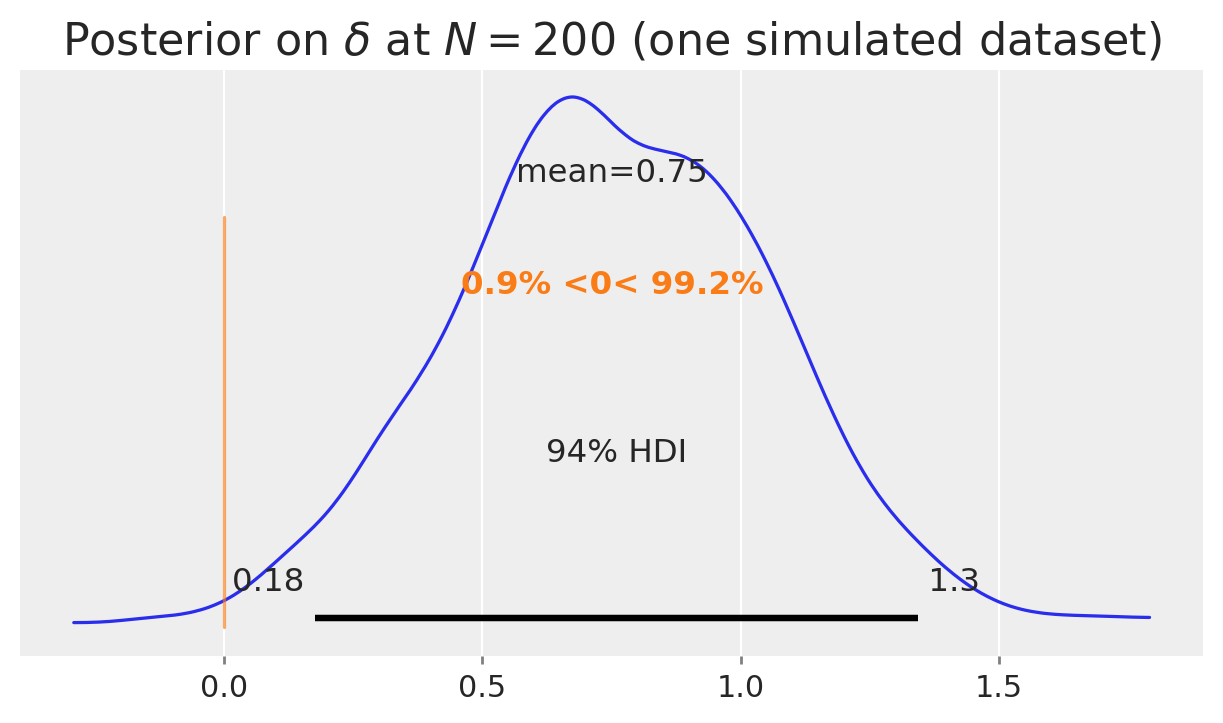

In [7]:
ax = az.plot_posterior(idata_gauss_demo, var_names=["delta"], ref_val=0.0, figsize=(6, 3.5))
ax.set_title(r"Posterior on $\delta$ at $N=200$ (one simulated dataset)");

The posterior concentrates above zero; under the decision rule the team would conclude the new flow lifts revenue. That is a single draw of the experiment. Assurance asks how often this conclusion would arrive if we re-ran the experiment many times under our actual prior.

The conjugate posterior on $\delta$ given $\hat d = \bar y_B - \bar y_A$ has mean and variance:

$$
\sigma_d^2 = \frac{2\sigma_{\text{obs}}^2}{N}, \quad
\tau^2_{\text{post}} = \left(\frac{1}{\tau_0^2} + \frac{1}{\sigma_d^2}\right)^{-1}, \quad
\mu_{\text{post}} = \tau^2_{\text{post}}\left(\frac{\mu_0}{\tau_0^2} + \frac{\hat d}{\sigma_d^2}\right),
$$

where $(\mu_0, \tau_0)$ is the prior on $\delta$. We check this matches the PyMC posterior before relying on it.

In [8]:
def gaussian_posterior_delta(d_hat, N, sigma_obs, prior):
    sigma_d_sq = 2 * sigma_obs**2 / N
    post_var = 1.0 / (1.0 / prior.sigma**2 + 1.0 / sigma_d_sq)
    post_mean = post_var * (prior.mu / prior.sigma**2 + d_hat / sigma_d_sq)
    return post_mean, np.sqrt(post_var)


d_hat_demo = y_B_demo.mean() - y_A_demo.mean()
analytical_mu, analytical_sd = gaussian_posterior_delta(
    d_hat_demo, N=200, sigma_obs=SIGMA_OBS, prior=EFFECT_PRIOR
)
mcmc_mu = idata_gauss_demo.posterior["delta"].mean().item()
mcmc_sd = idata_gauss_demo.posterior["delta"].std().item()

pd.DataFrame(
    {"analytical": [analytical_mu, analytical_sd], "MCMC": [mcmc_mu, mcmc_sd]},
    index=["posterior mean of delta", "posterior sd of delta"],
).round(3)

,analytical,MCMC
posterior mean of delta,0.745,0.751
posterior sd of delta,0.312,0.312


The two posteriors agree to within MCMC noise. The closed form will carry the decision step; the generative model will carry the data step.

In [9]:
def gaussian_assurance_at_N(N, n_sims, prior, sigma_obs, threshold, rng):
    seed = int(rng.integers(2**31 - 1))
    pp = pm.sample_prior_predictive(
        draws=n_sims, model=gaussian_generative_model(N, prior), random_seed=seed
    )
    y_A = pp.prior["y_A"].values.reshape(n_sims, N)
    y_B = pp.prior["y_B"].values.reshape(n_sims, N)
    d_hat = y_B.mean(axis=1) - y_A.mean(axis=1)
    post_mu, post_sd = gaussian_posterior_delta(d_hat, N, sigma_obs, prior)
    prob_positive = 1.0 - stats.norm.cdf(0.0, loc=post_mu, scale=post_sd)
    return float((prob_positive > threshold).mean())


N_GRID = np.array([100, 200, 400, 800, 1600, 3200, 6400])
N_SIMS = 1000

assurance_df = assurance_curve(
    gaussian_assurance_at_N,
    N_grid=N_GRID,
    n_sims=N_SIMS,
    rng=np.random.default_rng(RANDOM_SEED),
    prior=EFFECT_PRIOR,
    sigma_obs=SIGMA_OBS,
    threshold=DECISION_THRESHOLD,
)
assurance_df

Sampling: [delta, y_A, y_B]


Sampling: [delta, y_A, y_B]


Sampling: [delta, y_A, y_B]


Sampling: [delta, y_A, y_B]


Sampling: [delta, y_A, y_B]


Sampling: [delta, y_A, y_B]


Sampling: [delta, y_A, y_B]


,N,assurance
0,100,0.267
1,200,0.398
2,400,0.501
3,800,0.603
4,1600,0.640
5,3200,0.681
6,6400,0.717


For comparison we compute frequentist power at a single fixed effect size. The convention is to set the effect to the prior mean — which is itself an arbitrary choice, and a revealing one.

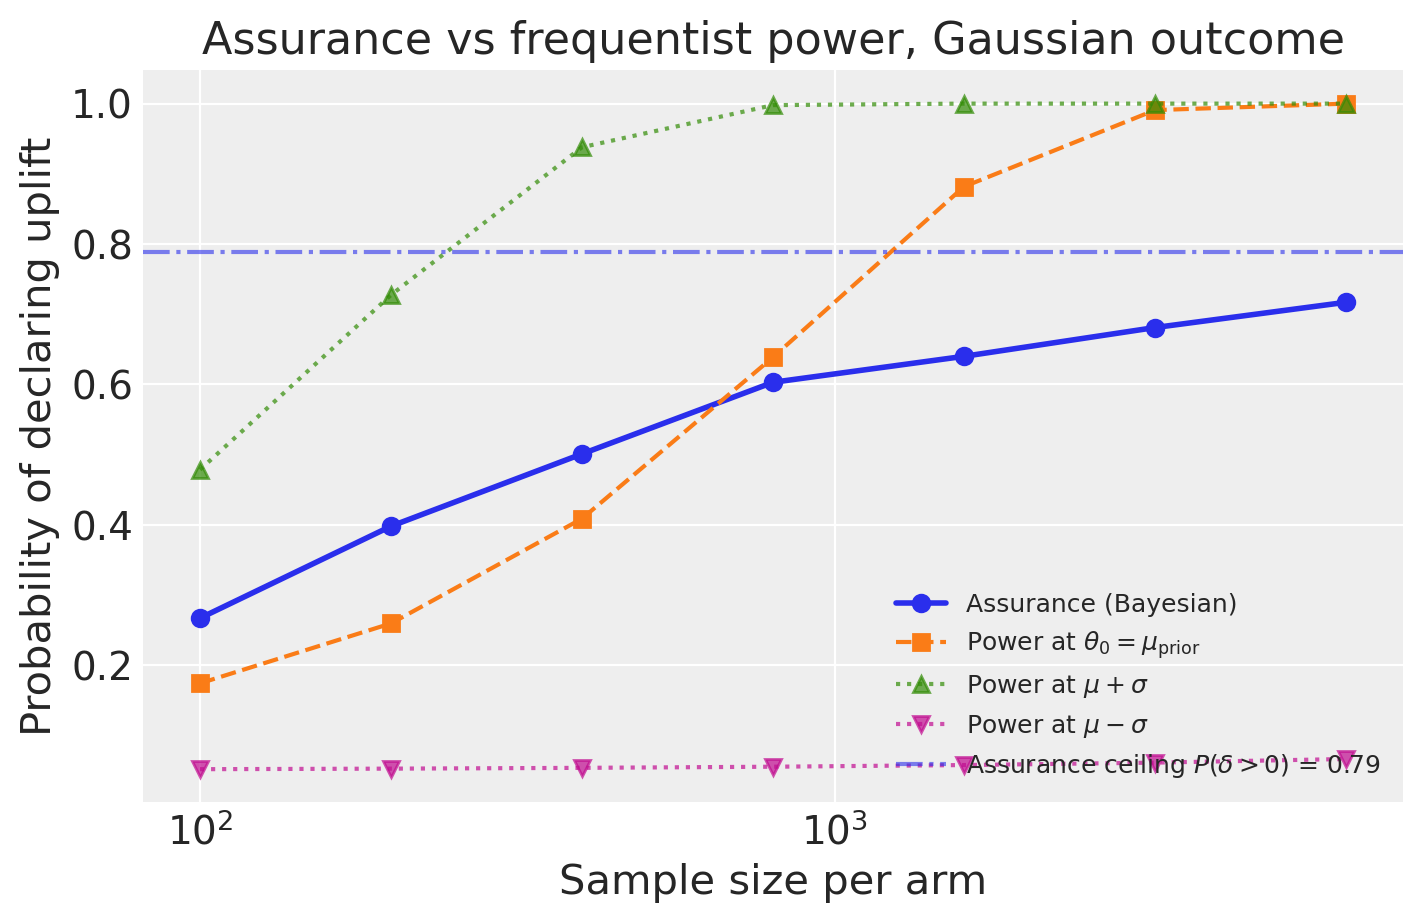

In [10]:
def gaussian_power(N, delta_alt, sigma_obs, alpha=0.05):
    sigma_d = np.sqrt(2 * sigma_obs**2 / N)
    z_crit = stats.norm.ppf(1 - alpha)
    return 1.0 - stats.norm.cdf(z_crit - delta_alt / sigma_d)


power_at_prior_mean = np.array([gaussian_power(N, EFFECT_PRIOR.mu, SIGMA_OBS) for N in N_GRID])
power_at_optimistic = np.array(
    [gaussian_power(N, EFFECT_PRIOR.mu + EFFECT_PRIOR.sigma, SIGMA_OBS) for N in N_GRID]
)
power_at_pessimistic = np.array(
    [gaussian_power(N, max(EFFECT_PRIOR.mu - EFFECT_PRIOR.sigma, 0.01), SIGMA_OBS) for N in N_GRID]
)

prior_prob_positive = 1.0 - stats.norm.cdf(0.0, EFFECT_PRIOR.mu, EFFECT_PRIOR.sigma)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(N_GRID, assurance_df["assurance"], marker="o", linewidth=2, label="Assurance (Bayesian)")
ax.plot(
    N_GRID,
    power_at_prior_mean,
    marker="s",
    linestyle="--",
    label=r"Power at $\theta_0 = \mu_{\text{prior}}$",
)
ax.plot(
    N_GRID,
    power_at_optimistic,
    marker="^",
    linestyle=":",
    alpha=0.7,
    label=r"Power at $\mu + \sigma$",
)
ax.plot(
    N_GRID,
    power_at_pessimistic,
    marker="v",
    linestyle=":",
    alpha=0.7,
    label=r"Power at $\mu - \sigma$",
)
ax.axhline(
    prior_prob_positive,
    color="C0",
    linestyle="-.",
    alpha=0.6,
    label=rf"Assurance ceiling $P(\delta>0)$ = {prior_prob_positive:.2f}",
)
ax.set_xscale("log")
ax.set_xlabel("Sample size per arm")
ax.set_ylabel("Probability of declaring uplift")
ax.set_title("Assurance vs frequentist power, Gaussian outcome")
ax.legend(loc="lower right", fontsize=9);

The three power curves fan out because each conditions on a single assumed world. Power at $\mu + \sigma$ assumes an effect of $0.9$ and saturates almost immediately; power at $\mu - \sigma$ is pinned near the test's five-percent floor, because $\mu - \sigma$ lands at essentially zero effect, where even large samples gain almost no detection. Power at the prior mean is the curve a frequentist planner would actually quote. The assurance curve is the prior-weighted integral across the entire fan, and it tells a different story than any single power calculation.

The story is in the crossing. Between $N=400$ and $N=800$ the assurance curve drops below power-at-the-mean, having sat above it at smaller samples. At small samples assurance is buoyed by the optimistic tail of the prior: it counts the plausible draws above $0.4$, effects of $0.8$ or $1.0$ that even a hundred observations have a real chance of detecting, which the single-point power calculation never sees. The frequentist who quotes power at the mean is being pessimistic about small experiments in a way the prior is not.

At large samples the relationship inverts, and the reason is the ceiling drawn above. Power at a fixed positive effect climbs to one: with enough data an effect of $0.4$ is certain to be detected. Assurance cannot reach one, because it carries the prior's honest admission that the effect might be zero or negative. Its asymptote is exactly the prior probability that the effect is beneficial, $P(\delta > 0) \approx 0.79$. No sample size buys more assurance than the prior's confidence that there is something to find, and that ceiling, rather than any point on a power curve, is the quantity a planner should internalise before paying for a larger experiment.

:::{admonition} The minimum detectable effect leads a double life
:class: note

Power is usually quoted at a "minimum detectable effect" (MDE), and that single number carries more weight than it appears to. Read one way, the MDE is a *utility threshold*: an effect smaller than this is not worth shipping, so failing to detect it does not matter, and powering at the MDE is a coherent design target. Read another way, it is a *forecast*: a quiet assumption that the true effect is about this large and positive, sometimes reverse-engineered from the sample size a team can already afford. The frequentist machinery itself is innocent here, because the false-positive rate $\alpha$ already governs the null case; it is the floor that the $\mu - \sigma$ curve traces. What conditions the null away is the reported summary, "$X\%$ power to detect the MDE", which is computed entirely inside the world where the effect is real and exactly the MDE. Assurance does not abolish this assumption. It relocates it from an implicit point to an explicit prior, where the probability that the effect is null or harmful becomes visible and open to argument.
:::

## The same machinery on a binary outcome

The conversion-rate version of this experiment is the canonical Bayesian A/B test setup, and the same machinery transfers without conceptual modification. The generative model fixes the baseline conversion rate, places the planning prior on the lift, and emits binomial counts per arm. The inference step places Beta priors on the per-arm rates and reads off the posterior probability that the lift is positive ({cite:p}`stucchio2015bayesian`, {cite:p}`kruschke2014doing`).

In [11]:
BASELINE_RATE = 0.10
RATE_LIFT_PRIOR = EffectPrior(mu=0.01, sigma=0.012)
BETA_PRIOR_KAPPA = 200  # prior concentration, in units of pseudo-observations


def beta_prior_params(p_mean, kappa):
    return kappa * p_mean, kappa * (1 - p_mean)


def bernoulli_generative_model(N, rate_prior, baseline_rate):
    """Unconditioned model: fixed baseline rate, planning prior on the lift, binomial counts per arm."""
    with pm.Model() as model:
        lift = pm.Normal("lift", mu=rate_prior.mu, sigma=rate_prior.sigma)
        p_B = pm.Deterministic("p_B", pm.math.clip(baseline_rate + lift, 1e-4, 1 - 1e-4))
        pm.Binomial("n_A", n=N, p=baseline_rate)
        pm.Binomial("n_B", n=N, p=p_B)
    return model


def bernoulli_assurance_at_N(
    N, n_sims, rate_prior, baseline_rate, kappa, threshold, rng, n_post=2000
):
    seed = int(rng.integers(2**31 - 1))
    pp = pm.sample_prior_predictive(
        draws=n_sims,
        model=bernoulli_generative_model(N, rate_prior, baseline_rate),
        random_seed=seed,
    )
    n_A = pp.prior["n_A"].values.reshape(-1).astype(int)
    n_B = pp.prior["n_B"].values.reshape(-1).astype(int)
    alpha0, beta0 = beta_prior_params(baseline_rate, kappa)
    p_A_post = rng.beta(alpha0 + n_A[:, None], beta0 + N - n_A[:, None], size=(n_sims, n_post))
    p_B_post = rng.beta(alpha0 + n_B[:, None], beta0 + N - n_B[:, None], size=(n_sims, n_post))
    prob_positive = (p_B_post > p_A_post).mean(axis=1)
    return float((prob_positive > threshold).mean())

Sampling: [lift, n_A, n_B]


Sampling: [lift, n_A, n_B]


Sampling: [lift, n_A, n_B]


Sampling: [lift, n_A, n_B]


Sampling: [lift, n_A, n_B]


Sampling: [lift, n_A, n_B]


Sampling: [lift, n_A, n_B]


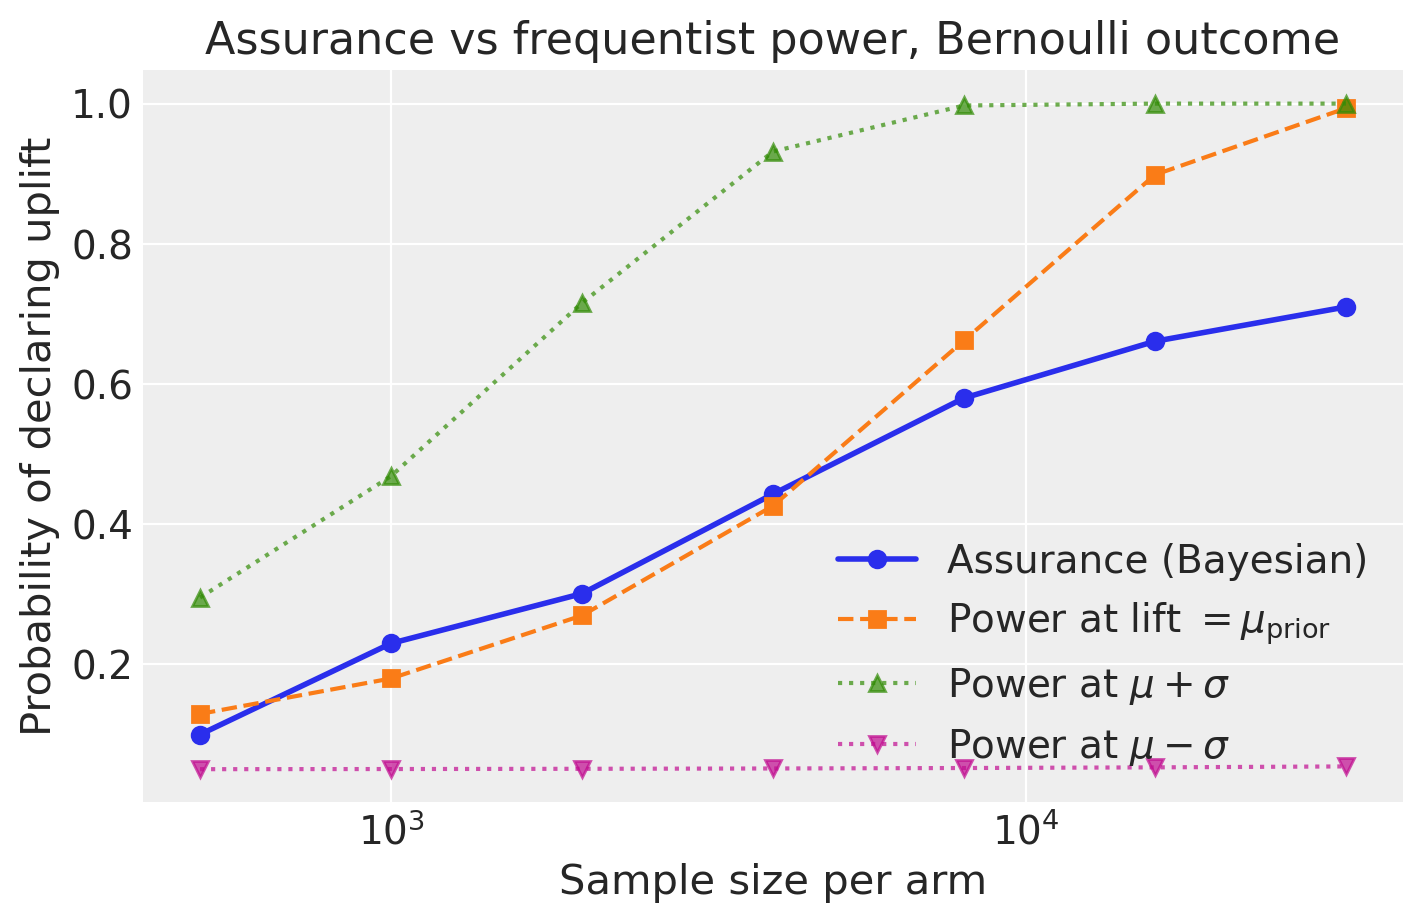

In [12]:
N_GRID_BERN = np.array([500, 1000, 2000, 4000, 8000, 16000, 32000])

assurance_bern_df = assurance_curve(
    bernoulli_assurance_at_N,
    N_grid=N_GRID_BERN,
    n_sims=N_SIMS,
    rng=np.random.default_rng(RANDOM_SEED),
    rate_prior=RATE_LIFT_PRIOR,
    baseline_rate=BASELINE_RATE,
    kappa=BETA_PRIOR_KAPPA,
    threshold=DECISION_THRESHOLD,
)


def bernoulli_power(N, p_A, lift_alt, alpha=0.05):
    p_B = p_A + lift_alt
    p_bar = 0.5 * (p_A + p_B)
    se_null = np.sqrt(2 * p_bar * (1 - p_bar) / N)
    se_alt = np.sqrt(p_A * (1 - p_A) / N + p_B * (1 - p_B) / N)
    z_crit = stats.norm.ppf(1 - alpha)
    return 1.0 - stats.norm.cdf((z_crit * se_null - lift_alt) / se_alt)


power_bern_at_prior_mean = np.array(
    [bernoulli_power(N, BASELINE_RATE, RATE_LIFT_PRIOR.mu) for N in N_GRID_BERN]
)
power_bern_at_optimistic = np.array(
    [
        bernoulli_power(N, BASELINE_RATE, RATE_LIFT_PRIOR.mu + RATE_LIFT_PRIOR.sigma)
        for N in N_GRID_BERN
    ]
)
power_bern_at_pessimistic = np.array(
    [
        bernoulli_power(N, BASELINE_RATE, max(RATE_LIFT_PRIOR.mu - RATE_LIFT_PRIOR.sigma, 1e-4))
        for N in N_GRID_BERN
    ]
)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(
    N_GRID_BERN,
    assurance_bern_df["assurance"],
    marker="o",
    linewidth=2,
    label="Assurance (Bayesian)",
)
ax.plot(
    N_GRID_BERN,
    power_bern_at_prior_mean,
    marker="s",
    linestyle="--",
    label=r"Power at lift $=\mu_{\text{prior}}$",
)
ax.plot(
    N_GRID_BERN,
    power_bern_at_optimistic,
    marker="^",
    linestyle=":",
    alpha=0.7,
    label=r"Power at $\mu + \sigma$",
)
ax.plot(
    N_GRID_BERN,
    power_bern_at_pessimistic,
    marker="v",
    linestyle=":",
    alpha=0.7,
    label=r"Power at $\mu - \sigma$",
)
ax.set_xscale("log")
ax.set_xlabel("Sample size per arm")
ax.set_ylabel("Probability of declaring uplift")
ax.set_title("Assurance vs frequentist power, Bernoulli outcome")
ax.legend(loc="lower right");

The picture is the same. Here the generative model produced the synthetic experiments and the conjugate Beta posterior supplied the decision, with no MCMC in the loop. We confirm below that the conjugate decision matches a full PyMC inference fit on a single dataset, so nothing in the assurance machinery depends on the closed form being available; it depends only on a posterior we can compute reliably.

Sampling: [n_A, n_B]


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [p_A, p_B]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


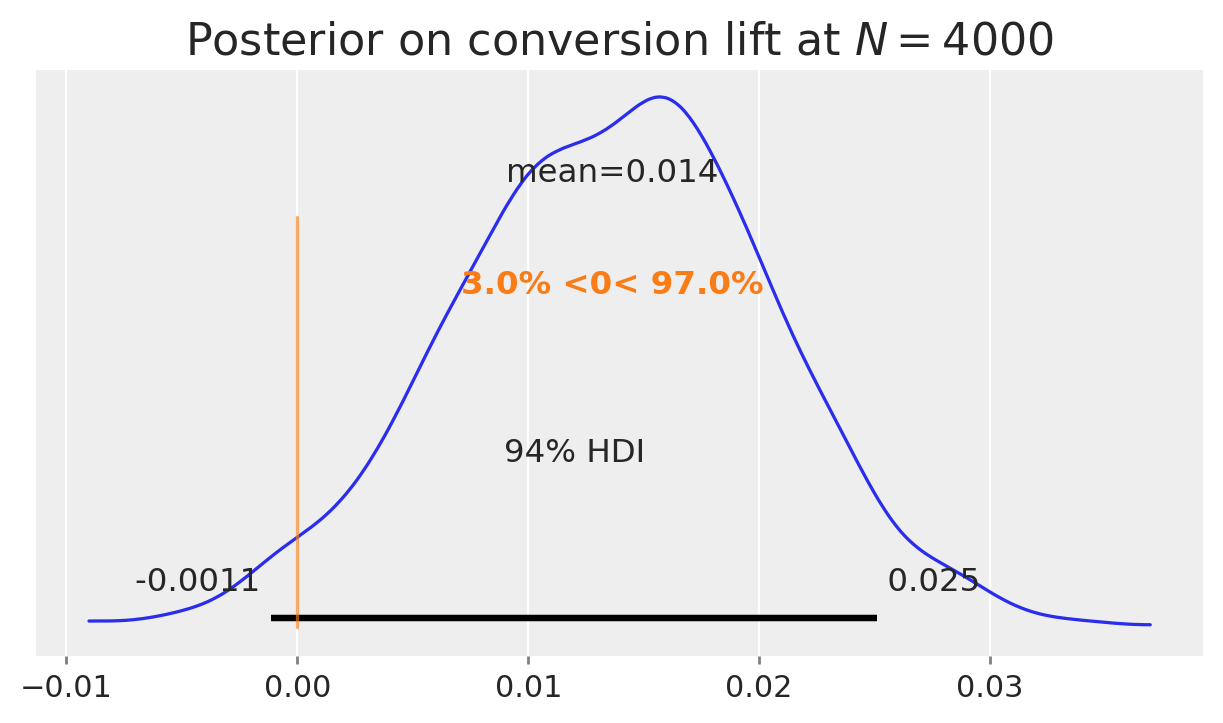

In [13]:
def bernoulli_two_arm_model(n_A, n_B, N, baseline_rate, kappa):
    alpha0, beta0 = beta_prior_params(baseline_rate, kappa)
    with pm.Model() as model:
        p_A = pm.Beta("p_A", alpha=alpha0, beta=beta0)
        p_B = pm.Beta("p_B", alpha=alpha0, beta=beta0)
        pm.Deterministic("lift", p_B - p_A)
        pm.Binomial("obs_A", n=N, p=p_A, observed=n_A)
        pm.Binomial("obs_B", n=N, p=p_B, observed=n_B)
    return model


demo_model_bern = pm.do(
    bernoulli_generative_model(N=4000, rate_prior=RATE_LIFT_PRIOR, baseline_rate=BASELINE_RATE),
    {"lift": 0.015},
)
demo_draw_bern = pm.sample_prior_predictive(draws=1, model=demo_model_bern, random_seed=RANDOM_SEED)
n_A_demo = int(demo_draw_bern.prior["n_A"].values.reshape(-1)[0])
n_B_demo = int(demo_draw_bern.prior["n_B"].values.reshape(-1)[0])

with bernoulli_two_arm_model(
    n_A_demo, n_B_demo, N=4000, baseline_rate=BASELINE_RATE, kappa=BETA_PRIOR_KAPPA
):
    idata_bern_demo = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.95,
        random_seed=RANDOM_SEED,
        progressbar=False,
    )

az.plot_posterior(idata_bern_demo, var_names=["lift"], ref_val=0.0, figsize=(6, 3.5))
plt.title(r"Posterior on conversion lift at $N=4000$");

The PyMC posterior on lift agrees with the conjugate Beta posterior, as it must under this setup. The machinery is the same.

## The cost of an under-informed prior

The assurance curve is conditional on the prior. A tightly informative prior centred near the truth produces an optimistic-looking curve; a flat prior produces a curve that requires substantially more data to reach the same assurance. Neither is wrong. They report what each prior commitment buys the planner.

Sampling: [delta, y_A, y_B]


Sampling: [delta, y_A, y_B]


Sampling: [delta, y_A, y_B]


Sampling: [delta, y_A, y_B]


Sampling: [delta, y_A, y_B]


...

Sampling: [delta, y_A, y_B]


Sampling: [delta, y_A, y_B]


Sampling: [delta, y_A, y_B]


Sampling: [delta, y_A, y_B]


Sampling: [delta, y_A, y_B]


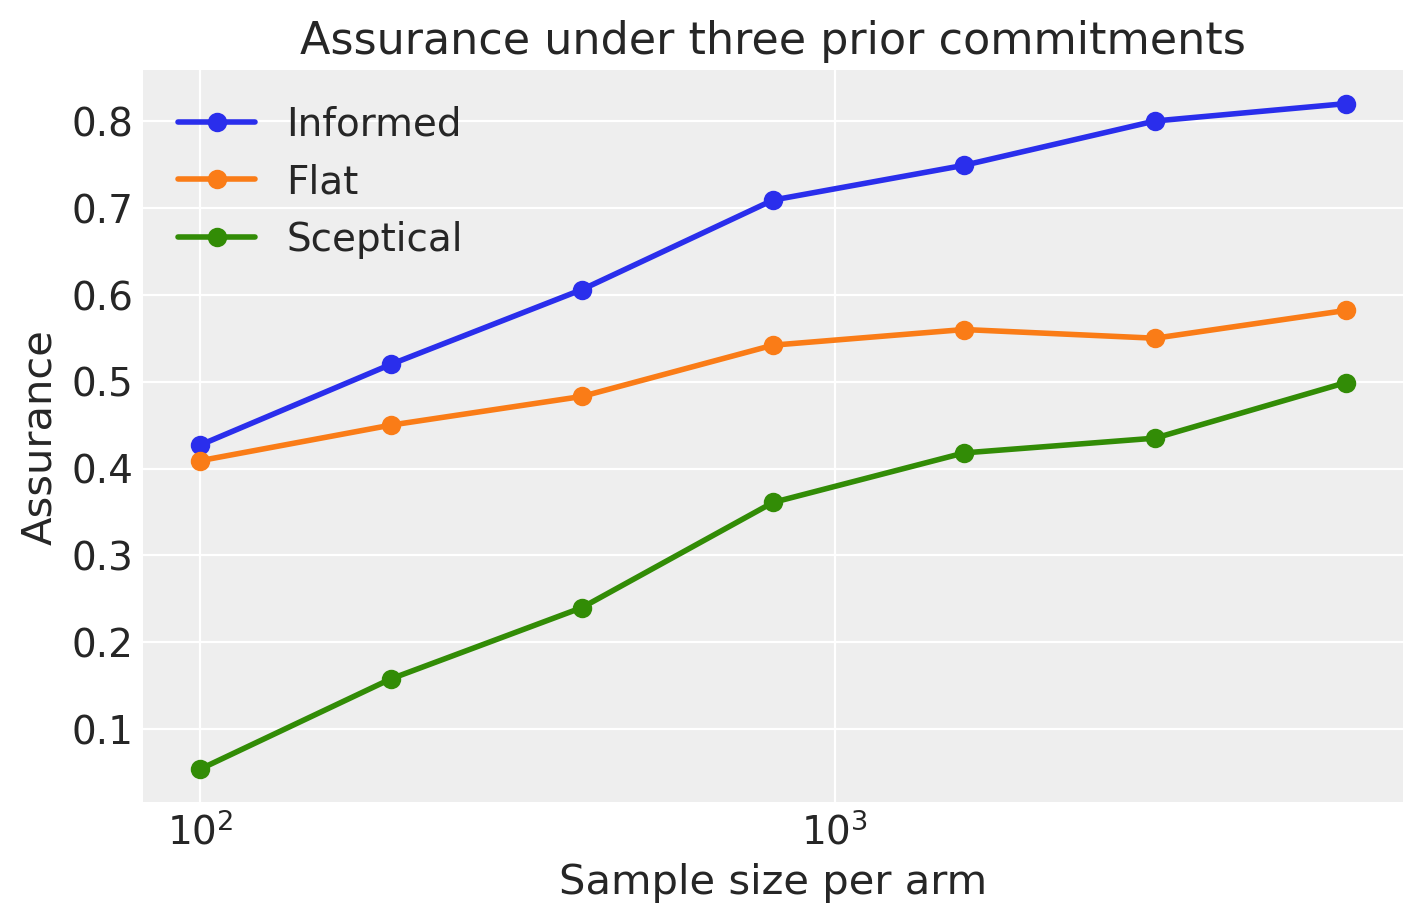

In [14]:
INFORMED_PRIOR = EffectPrior(mu=0.4, sigma=0.3)
FLAT_PRIOR = EffectPrior(mu=0.4, sigma=1.5)
SCEPTICAL_PRIOR = EffectPrior(mu=0.1, sigma=0.5)

prior_comparison = {}
for name, prior in [
    ("Informed", INFORMED_PRIOR),
    ("Flat", FLAT_PRIOR),
    ("Sceptical", SCEPTICAL_PRIOR),
]:
    df = assurance_curve(
        gaussian_assurance_at_N,
        N_grid=N_GRID,
        n_sims=N_SIMS,
        rng=np.random.default_rng(RANDOM_SEED),
        prior=prior,
        sigma_obs=SIGMA_OBS,
        threshold=DECISION_THRESHOLD,
    )
    prior_comparison[name] = df

fig, ax = plt.subplots(figsize=(7, 4.5))
for name, df in prior_comparison.items():
    ax.plot(df["N"], df["assurance"], marker="o", linewidth=2, label=name)
ax.set_xscale("log")
ax.set_xlabel("Sample size per arm")
ax.set_ylabel("Assurance")
ax.set_title("Assurance under three prior commitments")
ax.legend();

The three curves disagree most where they should: at small sample sizes where the data has not yet overwhelmed the prior. The informed prior reaches high assurance fastest because it is willing to commit to a narrow effect range; the sceptical prior assumes a smaller effect and so needs more data to detect it; the flat prior carries enough probability mass over zero that even moderate datasets do not push the posterior reliably above the decision threshold. The point is not to advocate for a specific prior. It is to make the dependence of the assurance number on the prior commitment visible, so that the prior can be the subject of negotiation rather than a hidden choice.

## Planning as a posterior over future posteriors

The experiment we have not yet run is a posterior we have not yet computed. What we have is a prior, a model, and the patience to ask what the experiment will likely say. Assurance is the posterior we can compute now, over the posteriors we will compute later: a rehearsal under the lights of our current uncertainty, and a fair one, because the lights are the only ones we have.

This re-frames the planning conversation. Power answers a conditional: given a specific effect, what probability of detection? Assurance answers a marginal: given everything currently believed, what probability the inference about to be drawn will be useful? The decision-theoretic operation that produces assurance is the same operation that produces the posterior at the end of the experiment. Only the data are still hypothetical. And it does its work by making explicit an assumption the power calculation leaves buried: that there is a believed distribution of effects at all. Naming the assumption a conventional analysis would rather not state, and giving it a posterior, is the move this sequence repeats.

In each case here, the Gaussian and the Bernoulli, the spine never changed. What changed was the likelihood. The same is true across this notebook and its successors. Planning, interpretation, synthesis are three questions the same machinery answers in turn; the posterior is the constant, the question changes. We have just seen the first of the three.

## Authors

- Authored by [Nathaniel Forde](https://nathanielf.github.io/) in May 2026.

## References

:::{bibliography}
:filter: docname in docnames
:::

## Watermark

In [15]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pytensor,xarray

Last updated: Thu May 28 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.8.0

pytensor: 2.38.2
xarray  : 2025.12.0

pymc      : 5.28.5
numpy     : 2.3.5
matplotlib: 3.10.8
seaborn   : 0.13.2
pandas    : 2.3.3
arviz     : 0.23.0
scipy     : 1.16.3

Watermark: 2.5.0



:::{include} ../page_footer.md
:::